In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd /Users/armandoroqueestrada/Proyecto_Proca/stability

/Users/armandoroqueestrada/Proyecto_Proca/Stability


In [3]:
import Modules.Background as bg
import numpy as np

import matplotlib.pyplot as plt
import Modules.Plot as cplot

import matplotlib.patches as patches

In [4]:
cplot.general()

In [5]:
# Filtrando datos
from collections import defaultdict

def dividir_ramas(datos):
    ramas = defaultdict(list)

    # Agrupar por x
    grupos = defaultdict(list)
    for x, y in datos:
        grupos[x].append(y)

    # Ordenar y asignar a ramas
    for x in sorted(grupos.keys()):  # mantiene orden creciente en x
        ys = sorted(grupos[x], reverse=True)  # mayor a menor
        for idx, y in enumerate(ys):
            ramas[idx].append([x, y])

    # Convertir a lista de listas
    return [ramas[k] for k in sorted(ramas.keys())]

In [7]:
# Load the data

# n = 0
Real_Eingevalues_cte_polarization_LNn0 = np.load("stability_lambda_n_case/Polarization_constant/Real_Eingevalues_cte_polarization_LNn0.npy", allow_pickle=True)
Real_Eingevalues_cte_polarization_LPn0 = np.load("stability_lambda_n_case/Polarization_constant/Real_Eingevalues_cte_polarization_LPn0.npy", allow_pickle=True)

# n = 1
Real_Eingevalues_cte_polarization_LNn1 = np.load("stability_lambda_n_case/Polarization_constant/Real_Eingevalues_cte_polarization_LNn1.npy", allow_pickle=True)
Real_Eingevalues_cte_polarization_LNn1_ext = np.load("stability_lambda_n_case/Polarization_constant/Real_Eingevalues_cte_polarization_LNn1_ext.npy", allow_pickle=True)

Real_Eingevalues_cte_polarization_LPn1 = np.load("stability_lambda_n_case/Polarization_constant/Real_Eingevalues_cte_polarization_LPn1.npy", allow_pickle=True)
Real_Eingevalues_cte_polarization_LPn1 = np.reshape(Real_Eingevalues_cte_polarization_LPn1, (81, 4, 5))
# Real_Eingevalues_cte_polarization_LPn1 =  np.load("Real_Eingevalues_cte_polarization_LPn1.npy", allow_pickle=True)

In [8]:
Family_cte_polarization_LNn0 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LNn0.npy", allow_pickle=True)
Family_cte_polarization_LNn1 = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LNn1.npy", allow_pickle=True)
Family_cte_polarization_LNn1_ext = np.load("/Users/armandoroqueestrada/Proyecto_Proca/Stability/background_data_profiles_lambda_n_case/Family_cte_polarization_LNn1_ext.npy", allow_pickle=True)

In [66]:
Real_Eingevalues_cte_polarization_LNn1.shape, Real_Eingevalues_cte_polarization_LNn1_ext.shape

((103, 4, 5), (3, 4, 5))

In [8]:
test = np.copy(Family_cte_polarization_LNn1)
for i, ins in enumerate(Family_cte_polarization_LNn1_ext):
    test = np.insert(test, 87 + i, ins, axis=0)

In [9]:
test2 = np.copy(Real_Eingevalues_cte_polarization_LNn1)
for i, ins in enumerate(Real_Eingevalues_cte_polarization_LNn1_ext):
    test2 = np.insert(test2, 87 + i, ins, axis=0)

In [30]:
test[89][2][0], Family_cte_polarization_LNn1[86][2][0], Family_cte_polarization_LNn1_ext[2][2][0]

(4.29567183, 3.8773057509493483, 4.29567183)

In [10]:
import Modules.EnergyMass as en

def find_nearest(array, value):
    n = [abs(i-value) for i in array]
    idx = n.index(min(n))

    indtest = list(array).index(max(array))

    if (indtest != len(array)-1) and (idx < indtest):
        array_test = array[indtest::]
        n = [abs(i-value) for i in array_test]
        idx = n.index(min(n))
        # print('-->', array_test[idx])
        idx = idx + (indtest - 1)

    return (array[idx], idx)

# Checking that all configurations have the same mass up to the first decimal point.
LambT, gamma = [-1, -1], 0
datosTemp = []
datosMasa = []
print('#'*10)
for ind, s0 in enumerate([Family_cte_polarization_LNn0, test]):  #Family_cte_polarization_LNn1
    MT, EnT = 0, 0
    dataTemp, temp = [], []
    for data in s0:
        Ei, rad, sDnew, dsDnew, uDnew, duDnew = data

        #plt.plot(rad, rad * sDnew)
        #plt.xlim(0, 30)
        #plt.show()
        ind2 = rad > 300

        Masa = en.massVal(rad, sDnew**2, gamma=gamma, integrationMetho='simpson') # 'quad')
        arg2 = [LambT[ind], gamma]  # Calculando la masa de la componente
        Enf, _, _ = en.EnFuncion([rad[ind2], sDnew[ind2], None], arg2)  # Calculando la energía de la componente
    
        temp.append([Ei, Masa, sDnew[0]])

        M99 = 0.99 * Masa
        #_, idx = find_nearest(Masa, M99)
        dataTemp.append([sDnew[0], M99])
        
    #print('Masa = %4.1f'%M99)
    datosTemp.append(temp)  # Guardando los datos
    datosMasa.append(dataTemp)
print('#'*10)

##########
##########


In [11]:
massn0 = np.array(datosMasa[0])
massn1 = np.array(datosMasa[1])

sigMaxn0 = massn0[massn0[:, 1].argmax(), 0]
sigMaxn1 = massn1[massn1[:, 1].argmax(), 0]

sigMaxn0, sigMaxn1

(1.0, 4.15621647)

/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/armandoroqueestrada/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.25, 0.25, 'stable band')

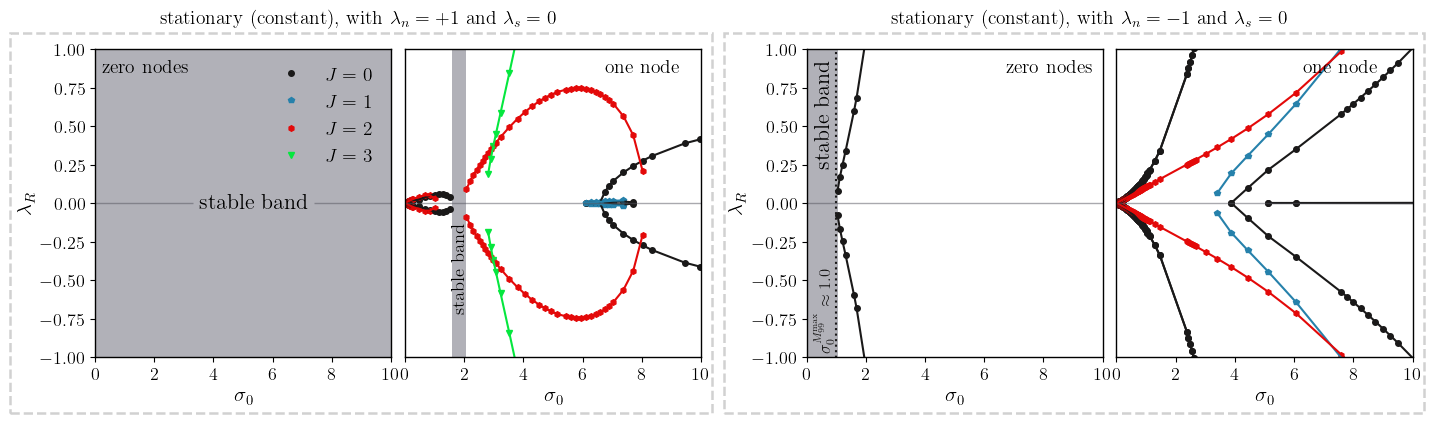

In [9]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 4.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

############################################################
# [Jval_temp, s0, r, eingVal, eigVect]
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            y = eingVal
            x = [s0] * len(y)
            if cont == 0:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

      ax[0].legend(frameon=False, fontsize=14)

############################################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': []}, {'0': [], '1': [], '2': [], '3': []}
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn1):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            if len(y) == 0:
                x, y = [None], [None]
            else:
                y = list(set(np.round(np.real(y), decimals=8)))
                x = [s0] * len(y)

            if cont == 0:
                ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if  mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[1].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[1].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])
        # ax[1].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])


############################################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': []}, {'0': [], '1': [], '2': [], '3': []}
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LNn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            x = [s0] * len(y)
            if cont == 0:
                  ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if  mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[2].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        ax[2].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])

ax[2].vlines(x=1.0, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
ax[2].text(x=0.22, y=-.95, s=r'$\sigma_0^{M^{\mathrm{max}}_{99}}\approx1.0$', color=col[0], rotation=90, fontsize=12)

########################################################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': []}, {'0': [], '1': [], '2': [], '3': []}
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LNn1):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 2e-05 # filtrando los autovalores reales
            y = eingVal[ind]
            x = [s0] * len(y)
            if cont == 0:
                  ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if  mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)

    plot_branch_P = dividir_ramas(tempP[key])
    #plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[3].plot(np.array(plot_branch_P[i])[:, 0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[3].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])
        # ax[3].plot(np.array(plot_branch_N[i])[:, 0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])

########################################################################    
ax[1].set_yticks([])
ax[3].set_yticks([])
ax[0].set_ylabel(r'$\lambda_{R}$')
ax[2].set_ylabel(r'$\lambda_{R}$')

ax[0].text(x=0.25, y=0.85, s=r'zero nodes', fontsize=14)
ax[2].text(x=6.75, y=0.85, s=r'zero nodes', fontsize=14)
ax[1].text(x=6.75, y=0.85, s=r'one node', fontsize=14)
ax[3].text(x=6.3, y=0.85, s=r'one node', fontsize=14)


# Añadir un marco exterior
rectIzq = patches.Rectangle(
    (0.075, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.413,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,  #'#55555e'
    facecolor="none",
    transform=fig.transFigure,
    zorder=10
)

rectDerec = patches.Rectangle(
    (0.495, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.412,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,
    facecolor='none',
    transform=fig.transFigure,
    zorder=10
)

fig.patches.append(rectIzq)
fig.patches.append(rectDerec)

# Añadir una etiqueta para el marco exterior
fig.text(
    x=0.28, y=0.98,                    # posición (x, y) relativa a la figura
    s=r'stationary (constant), with $\lambda_n= + 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

fig.text(
    x=0.71, y=0.98,                    # posición (x, y) relativa a la figura
    s=r'stationary (constant), with $\lambda_n= - 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

# Obtener posiciones originales
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Acercar la segunda y tercera columna
ax[1].set_position([pos2.x0 - 0.018, pos2.y0, pos2.width, pos2.height])
ax[2].set_position([pos3.x0 + 0.018, pos3.y0, pos3.width, pos3.height])

for axes in ax:
    axes.set_xlim(0, 10.)
    axes.set_ylim(-1., 1.)
    axes.set_xlabel(r'$\sigma_0$')

ax[0].hlines(y=0, xmin=0, xmax=3.3, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[0].hlines(y=0, xmin=7.4, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[1].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[2].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[3].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[0].axvspan(0, 10, facecolor='#656473', alpha=0.5)
ax[1].axvspan(1.6, 2.07, facecolor='#656473', alpha=0.5)

ax[0].text(3.5, -0.03, s=r'stable band', rotation='horizontal')#, fontsize='small'
ax[1].text(1.58, -.7, s=r'stable band', rotation='vertical', fontsize='small')

ax[2].axvspan(0, 1.046, facecolor='#656473', alpha=0.5)
ax[2].text(0.25, .25, s=r'stable band', rotation='vertical')#, fontsize='small'

Text(0.25, 0.25, 'stable band')

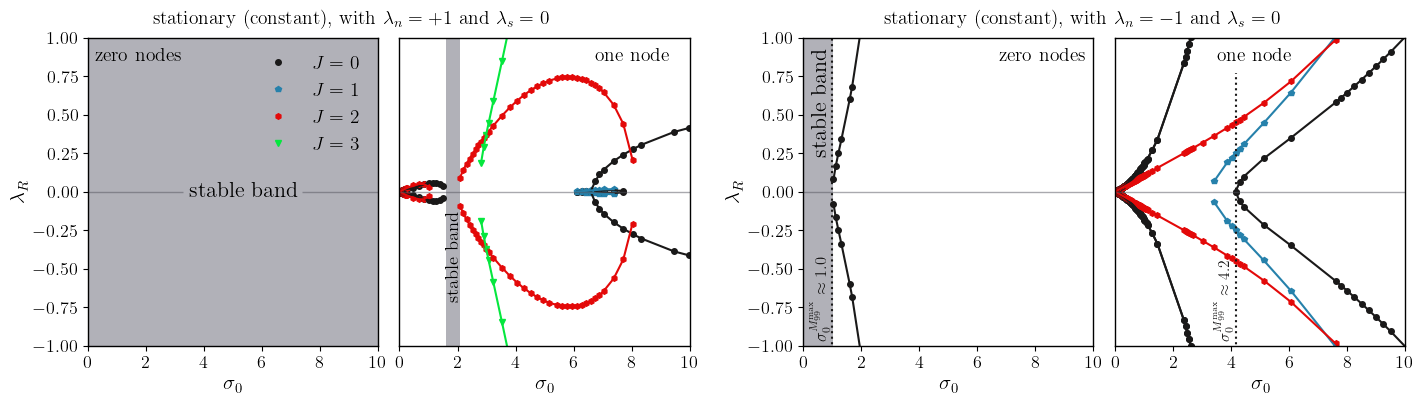

In [59]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 4.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.5, wspace=.18) # espacio vertical y horizontal entre los subplots
                      )

############################################################
# [Jval_temp, s0, r, eingVal, eigVect]
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            y = eingVal
            x = [s0] * len(y)
            if cont == 0:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[0].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

      ax[0].legend(frameon=False, fontsize=14)

############################################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': []}, {'0': [], '1': [], '2': [], '3': []}
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn1):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            if len(y) == 0:
                x, y = [None], [None]
            else:
                y = list(set(np.round(np.real(y), decimals=8)))
                x = [s0] * len(y)

            if cont == 0:
                ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                ax[1].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)

            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if  mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    # plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[1].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[1].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])
        # ax[1].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])


############################################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': []}, {'0': [], '1': [], '2': [], '3': []}
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LNn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales 8e-06
            y = eingVal[ind]
            x = [s0] * len(y)
            if cont == 0:
                  ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[2].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if  mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)
    plot_branch_P = dividir_ramas(tempP[key])
    plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[2].plot(np.array(plot_branch_P[i])[:,0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        ax[2].plot(np.array(plot_branch_N[i])[:,0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])

ax[2].vlines(x=sigMaxn0, ymin=-1.6, ymax=1.5, ls=':', lw=1.5, color=col[0])
ax[2].text(x=0.22, y=-.95, s=r'$\sigma_0^{M^{\mathrm{max}}_{99}}\approx %2.1f$'%sigMaxn0, color=col[0], rotation=90, fontsize=12)

########################################################################
tempP, tempN = {'0': [], '1': [], '2': [], '3': []}, {'0': [], '1': [], '2': [], '3': []}
for cont, dataExtra in enumerate(test2):  # Real_Eingevalues_cte_polarization_LNn1
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            if s0 > 5:
                ind = np.abs(np.real(eingVal)) >= 3e-04
            else:
                ind = np.abs(np.real(eingVal)) >= 1e-04 # filtrando los autovalores reales
            
            y = eingVal[ind]
            x = [s0] * len(y)
            if cont == 0:
                  ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4, label=r'$J=%d$'%Jval_temp)
            else:
                  ax[3].plot(x, y, ls='', color=col[cond2], marker=mark[cond2], markersize=4)
            
            if len(y) == 0:
                y = [None]
            
            for mod in np.real(y):
                if  mod is None or mod > 0:
                    tempP[str(Jval_temp)].append([s0, mod])
                if mod is None or mod < 0:
                    tempN[str(Jval_temp)].append([s0, mod])

for cond2, key in enumerate(tempP.keys()):
    tempP[key] = np.array(tempP[key], dtype=object)
    # tempN[key] = np.array(tempN[key], dtype=object)

    plot_branch_P = dividir_ramas(tempP[key])
    #plot_branch_N = dividir_ramas(tempN[key])
    for i in range(len(plot_branch_P)):
        ax[3].plot(np.array(plot_branch_P[i])[:, 0], np.array(plot_branch_P[i])[:, 1], color=col[cond2])
        arr_neg = np.array([x * -1 if x is not None else None for x in np.array(plot_branch_P[i])[:, 1]], dtype=object)
        ax[3].plot(np.array(plot_branch_P[i])[:, 0], arr_neg, color=col[cond2])
        # ax[3].plot(np.array(plot_branch_N[i])[:, 0], np.array(plot_branch_N[i])[:, 1], color=col[cond2])

ax[3].vlines(x=sigMaxn1, ymin=-1.6, ymax=.77, ls=':', lw=1.5, color=col[0])
ax[3].text(x=sigMaxn1 - 0.8, y=-.95, s=r'$\sigma_0^{M^{\mathrm{max}}_{99}}\approx %2.1f$'%sigMaxn1, color=col[0], rotation=90, fontsize=11, zorder=100)
########################################################################   


ax[1].set_yticks([])
ax[3].set_yticks([])
ax[0].set_ylabel(r'$\lambda_{R}$')
ax[2].set_ylabel(r'$\lambda_{R}$')

ax[0].text(x=0.25, y=0.85, s=r'zero nodes', fontsize=14)
ax[2].text(x=6.75, y=0.85, s=r'zero nodes', fontsize=14)
ax[1].text(x=6.75, y=0.85, s=r'one node', fontsize=14)
ax[3].text(x=3.5, y=0.85, s=r'one node', fontsize=14)


# Añadir un marco exterior
rectIzq = patches.Rectangle(
    (0.075, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.413,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,  #'#55555e'
    facecolor="none",
    transform=fig.transFigure,
    zorder=10
)

rectDerec = patches.Rectangle(
    (0.495, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.412,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,
    facecolor='none',
    transform=fig.transFigure,
    zorder=10
)

#fig.patches.append(rectIzq)
#fig.patches.append(rectDerec)

# Añadir una etiqueta para el marco exterior
fig.text(
    x=0.28, y=0.95,                    # posición (x, y) relativa a la figura
    s=r'stationary (constant), with $\lambda_n= + 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

fig.text(
    x=0.71, y=0.95,                    # posición (x, y) relativa a la figura
    s=r'stationary (constant), with $\lambda_n= - 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

# Obtener posiciones originales
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Acercar la segunda y tercera columna
ax[1].set_position([pos2.x0 - 0.018, pos2.y0, pos2.width, pos2.height])
ax[2].set_position([pos3.x0 + 0.018, pos3.y0, pos3.width, pos3.height])

for axes in ax:
    axes.set_xlim(0, 10.)
    axes.set_ylim(-1., 1.)
    axes.set_xlabel(r'$\sigma_0$')

ax[0].hlines(y=0, xmin=0, xmax=3.3, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[0].hlines(y=0, xmin=7.4, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[1].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[2].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)
ax[3].hlines(y=0, xmin=0, xmax=11.5, ls='-', lw=1, color='#55555e', alpha=0.5)

ax[0].axvspan(0, 10, facecolor='#656473', alpha=0.5)
ax[1].axvspan(1.6, 2.07, facecolor='#656473', alpha=0.5)

ax[0].text(3.5, -0.03, s=r'stable band', rotation='horizontal')#, fontsize='small'
ax[1].text(1.58, -.7, s=r'stable band', rotation='vertical', fontsize='small')

ax[2].axvspan(0, 1.046, facecolor='#656473', alpha=0.5)
ax[2].text(0.25, .25, s=r'stable band', rotation='vertical')#, fontsize='small'

In [60]:
fig.savefig('stationary_cte_lambda.pdf', format='pdf', metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )

In [97]:
def find_indices_between_none(data):
    ranges = []
    start = None

    for i, value in enumerate(data):
        if value is not None:
            if start is None:
                start = i
        else:
            if start is not None:
                ranges.append((start, i - 1))
                start = None

    # Check if the list ends without a trailing None
    if start is not None:
        ranges.append((start, len(data) - 1))

    return ranges 

def limites(data):
    ranges_J = [[] for _ in range(len(data))]
    
    Jvalues = []
    for cont, Jdata in enumerate(data):
        Jdata = np.array(Jdata)
        
        Jvalcheck = Jdata[0, 0]
        if sum(Jdata[:, 0]==Jvalcheck) != len(Jdata):
            raise ValueError("Not all J-values are %d"%Jvalcheck)
        
        Jvalues.append(Jvalcheck)
        
        # Find the interval
        dataJ = Jdata[:, 1]
        ranges = find_indices_between_none(dataJ)
        if len(ranges) != 0:
            # (dataJ[ind[0]], dataJ[ind[1]]) for ind in ranges)
            for ind in ranges:
                ranges_J[cont].append((dataJ[ind[0]], dataJ[ind[1]]))
        else:
            ranges_J[cont].append([])

    return Jvalues, ranges_J


def columloca(ax, columdata, color, columNumb=1, height=0.5, alpha=0.85):
    loc = (2*columNumb-1)*(height/2)
    ncol = len(columdata)
    for i in range(ncol):
        dat = columdata[i]
        
        if len(dat) != 0:
            delta = abs(dat[1]-dat[0])
            widths = delta # dat[1] #None if starts is None else dat-starts
            starts = dat[0] #if starts is None else starts
        else:
            starts, widths = None, None
        if widths is not None:
            ax.barh([loc], widths, left=starts, height=height, color=color,
                    edgecolor='black',
                    linewidth=0.05,
                    ls='-',
                    #hatch='/',
                    alpha=alpha)
    
    return ax

[]

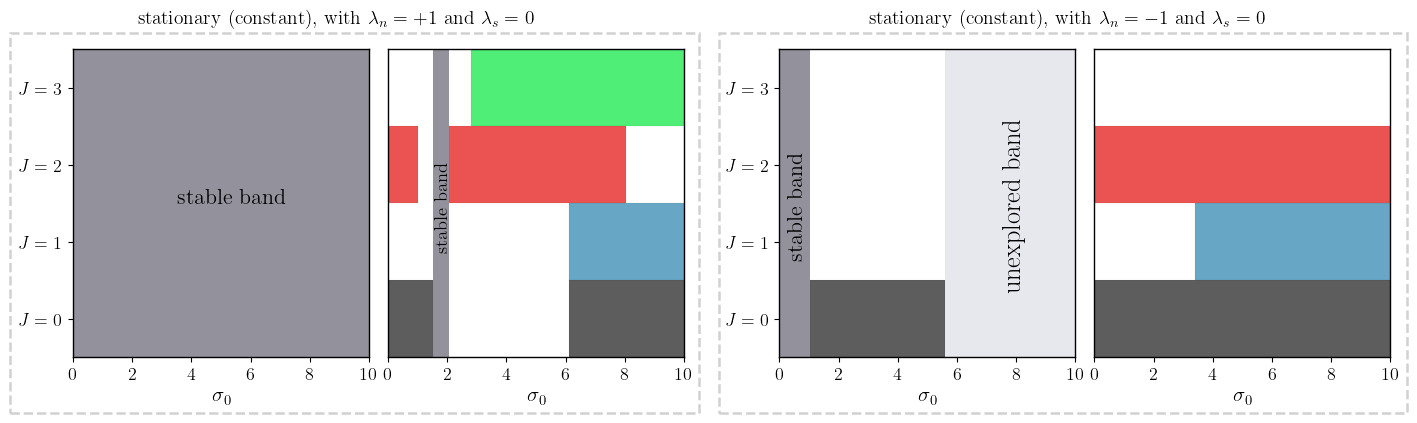

In [105]:
col = ['#1a1919', '#2681ab', "#e30909", "#05e73e"]
mark = ['o', 'p', 'h', 'v']

height = 0.5

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(17, 4.),
                       sharex=False, sharey=False,
                       gridspec_kw=dict(hspace=0.5, wspace=.15) # espacio vertical y horizontal entre los subplots
                      )

# [Jval_temp, s0, r, eingVal, eigVect]
Jval_interv = [[] for _ in range(4)]  # J = 0, 1, 2, 3
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            if y.size !=0:
                Jval_interv[cond2].append([Jval_temp, s0])
            else:
                Jval_interv[cond2].append([Jval_temp, None])
     
LPn0Jvalues, LPn0ranges_J = limites(Jval_interv)
for colNumb, n0columnLP in enumerate(LPn0ranges_J, start=1):
    columloca(ax[0], n0columnLP, columNumb=colNumb, color=col[colNumb-1], height=height)

##########################################
Jval_interv = [[] for _ in range(4)]  # J = 0, 1, 2, 3
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LPn1):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            if y.size !=0:
                Jval_interv[cond2].append([Jval_temp, s0])
            else:
                Jval_interv[cond2].append([Jval_temp, None])

LPn0Jvalues, LPn0ranges_J = limites(Jval_interv)
for colNumb, n0columnLP in enumerate(LPn0ranges_J, start=1):
    if colNumb==2:
        n0columnLP = [(n0columnLP[0][0], 10.46418764571049)]
    columloca(ax[1], n0columnLP, columNumb=colNumb, color=col[colNumb-1], height=height,  alpha=0.7)

##########################################
Jval_interv = [[] for _ in range(4)]  # J = 0, 1, 2, 3
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LNn0):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            if y.size !=0:
                Jval_interv[cond2].append([Jval_temp, s0])
            else:
                Jval_interv[cond2].append([Jval_temp, None])
     
LPn0Jvalues, LPn0ranges_J = limites(Jval_interv)
for colNumb, n0columnLP in enumerate(LPn0ranges_J, start=1):
    if colNumb==1:
        n0columnLP = [(n0columnLP[0][0], 5.6)]
    columloca(ax[2], n0columnLP, columNumb=colNumb, color=col[colNumb-1], height=height,  alpha=0.7)

##########################################
Jval_interv = [[] for _ in range(4)]  # J = 0, 1, 2, 3
for cont, dataExtra in enumerate(Real_Eingevalues_cte_polarization_LNn1):
      for cond2, [Jval_temp, s0, _, eingVal, _] in enumerate(dataExtra):
            ind = np.abs(np.real(eingVal)) >= 8e-06 # filtrando los autovalores reales
            y = eingVal[ind]
            if y.size !=0:
                Jval_interv[cond2].append([Jval_temp, s0])
            else:
                Jval_interv[cond2].append([Jval_temp, None])
     
LPn0Jvalues, LPn0ranges_J = limites(Jval_interv)
for colNumb, n0columnLP in enumerate(LPn0ranges_J, start=1):
    columloca(ax[3], n0columnLP, columNumb=colNumb, color=col[colNumb-1], height=height,  alpha=0.7)

####################################################################################
# Añadir un marco exterior
rectIzq = patches.Rectangle(
    (0.088, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.405,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,  #'#55555e'
    facecolor="none",
    transform=fig.transFigure,
    zorder=10
)

rectDerec = patches.Rectangle(
    (0.505, -0.03),     # esquina inferior izquierda (relativa a la figura)
    0.405,              # ancho
    0.95,              # alto
    linewidth=1.8,
    ls='--',
    edgecolor='#1a1919', alpha=0.2,
    facecolor='none',
    transform=fig.transFigure,
    zorder=10
)

fig.patches.append(rectIzq)
fig.patches.append(rectDerec)

# Añadir una etiqueta para el marco exterior
fig.text(
    x=0.28, y=0.98,                    # posición (x, y) relativa a la figura
    s=r'stationary (constant), with $\lambda_n= + 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

fig.text(
    x=0.71, y=0.98,                    # posición (x, y) relativa a la figura
    s=r'stationary (constant), with $\lambda_n= - 1$ and $\lambda_s=0$',          # texto
    ha='center', va='top',        # alineación horizontal y vertical
    fontsize=14, color='k',
    weight='bold'
)

# Obtener posiciones originales
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Acercar la segunda y tercera columna
ax[1].set_position([pos2.x0 - 0.015, pos2.y0, pos2.width, pos2.height])
ax[2].set_position([pos3.x0 + 0.015, pos3.y0, pos3.width, pos3.height])


##############
Lvalores = [r'$J=%d$'%i for i in LPn0Jvalues]
NumL = len(LPn0Jvalues)
yloc = [(2*i-1)*(height/2) for i in range(1, NumL+1)]
ax[0].set_yticks(ticks=yloc, labels=Lvalores)
ax[2].set_yticks(ticks=yloc, labels=Lvalores)

for axes in ax:
    axes.set_xlim(0, 10.)
    axes.set_ylim(0, max(yloc)+height/2) 
    axes.set_xlabel(r'$\sigma_0$')

############
ax[0].axvspan(0, 10, facecolor='#656473', alpha=0.7)
ax[1].axvspan(1.53, 2.07, facecolor='#656473', alpha=0.7)

ax[0].text(3.5, 1., s=r'stable band', rotation='horizontal')#, fontsize='small'
ax[1].text(1.58, .7, s=r'stable band', rotation='vertical', fontsize='small')

ax[2].axvspan(0, 1.046, facecolor='#656473', alpha=0.7)
ax[2].text(0.25, .65, s=r'stable band', rotation='vertical')#, fontsize='small'


ax[2].axvspan(5.61171, 10, facecolor="#DDDDE7", alpha=0.7, hatch='')
ax[2].text(7.5, .45, s=r'unexplored band', fontsize=19, rotation='vertical', zorder=100)#, fontsize='small'

########################
ax[1].set_yticks([])
ax[3].set_yticks([])

#ax[0].text(x=0.25, y=0.85, s=r'zero nodes', fontsize=14)
#ax[2].text(x=6.75, y=0.85, s=r'zero nodes', fontsize=14)
#ax[1].text(x=0.25, y=0.85, s=r'one node', fontsize=14)
#ax[3].text(x=6.3, y=0.85, s=r'one node', fontsize=14)

In [106]:
fig.savefig('stationary_cte_lambda2.pdf', format='pdf', metadata=None, # dpi='figure',
        pad_inches=0.1,
        facecolor='auto', edgecolor='auto',
        backend=None, dpi=1000, 
        bbox_inches='tight'# Plot will be occupy a maximum of available space # bbox_inches=None,
       )